In [7]:
import numpy as np
import scipy.io
from sklearn import metrics
import pandas as pd
import os
import scipy.io as sio
import os.path
import time
import random
import math
# os.environ['THEANO_FLAGS'] = "device=cuda0,force_device=True,floatX=float32"
# from aesara_theano_fallback import aesara as theano
#import theano

# print(theano.config.device)
# import sys, getopt
# import tensorflow.keras as keras
# import tensorflow as tf
import matplotlib.pyplot as plt

# from keras.layers import Embedding
# from keras.models import Model
# from keras.layers import Dense, Dropout, Activation, Flatten, Layer, merge, Input, Concatenate, Reshape
# from keras.layers.convolutional import Conv1D, MaxPooling1D
# from keras.layers.pooling import GlobalMaxPooling1D
# from keras.layers.recurrent import LSTM
# from keras.layers.wrappers import Bidirectional, TimeDistributed
# from keras.models import load_model
# from keras.callbacks import ModelCheckpoint, EarlyStopping
# from keras import backend as K

In [8]:
def readInputAsArray(fileName):
    with open(fileName, 'r') as myfile:
        data = myfile.readlines()

    # Strip newline
    for i in range(0, len(data)):
        data[i] = data[i].rstrip()
    # print(data)
    return data

def readInputAsString(fileName):
    with open(fileName, 'r') as myfile:
        data=myfile.read().replace('\n', ' ')
        # print 
    return data

def reverse_complement(seq):    
    complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
    reverse_complement = ''.join(complement.get(base, base) for base in reversed(seq))
    return reverse_complement

def oneHotEncode(seq):
    import numpy as np
    seq2=list()
    mapping = {"A":[1., 0., 0., 0.], "C": [0., 1., 0., 0.], "G": [0., 0., 1., 0.], "T":[0., 0., 0., 1.]};
    for i in seq:
    	seq2.append(mapping[i]  if i in mapping.keys() else [0., 0., 0., 0.]);
    return seq2;

def ReverseOneHotEncode(arr):
    seq = ''
    nuc_map = ['A', 'C', 'G', 'T']
    for subarr in arr:
        nuc = nuc_map[np.argmax(subarr)]
        seq+=nuc
    return seq;

def writeSeqToFile(d,ones,zeros):
    fname = '/Users/yibeijia/Downloads/nucleosome_occupancy/data/SeqsForFeature.txt'
    out = 'Enriched:\n'
    for i in ones:
        seq = ReverseOneHotEncode(d[i])
        out = out + str(1) + ' ' + seq + '\n'
    out += 'Depleted:\n'
    for i in zeros:
        seq = ReverseOneHotEncode(d[i])
        out = out + str(0) + ' ' + seq + '\n'
    with open(fname, 'w+') as f:
        f.write(out)

In [9]:
# I/O function
def read_SD_table(fileName):
    tb_data = readInputAsArray(fileName)
    tb = {}
    DNAshape = tb_data[0].split("\t")
    # print(DNAshape)
    for i in range(1, len(tb_data)):
        line = tb_data[i].split("\t")
        key = line[0]
        value = line[1:]
        for j in range(0, len(value)):
            value[j] = float(value[j])
        tb[key] = value
    # print(tb)
    return(tb)

# Normalize an array 
def min_max_norm(arr):
    new_arr = []
    min_v = min(arr)
    max_v = max(arr)
    for num in arr:
        new_arr=new_arr+[(num-min_v)/(max_v-min_v)]
    return(new_arr)

# Given a sequence, return an array of pentamer shape values

def SD_calculation(seq, tb, DNAshape):
    N=10 # calculate SD value for every 10 bps
    shape_values = []

    #Initial the first pentamer
    pentamer = RevOneHotEncode(seq[0:5])
    if pentamer not in tb.keys():
        pentamer = reverse_complement(pentamer)
    for i in range(len(DNAshape)):
        shape_values.append(tb.get(pentamer)[i])

    for i in range(1, len(seq)-5):
        pentamer = RevOneHotEncode(seq[i:i+5])
        if pentamer not in tb.keys():
            pentamer = reverse_complement(pentamer)
        else:
            for j in range(0, len(DNAshape)):
                shape_values[j] = shape_values[j] + tb.get(pentamer)[j]
    return shape_values;

def nucseq_shape_analysis(fname, out, DNAshape, tb):

    # Open and read file
    if os.path.isfile(fname):
        mat_contents = sio.loadmat(fname)
        edata=mat_contents['EnrichedData']
        ddata=mat_contents['DepletedData']
#     print(tb)

    shapes = []
    np_allEnrichSeqArr = np.array(edata)
    np_allDepleteSeqArr = np.array(ddata)
    print(f"3 np_allEnrichSeqArr.shape {np_allEnrichSeqArr.shape}, np_allDepleteSeqArr.shape {np_allDepleteSeqArr.shape}");
    for d in ddata:
        if 'N' not in d:
            shape_values = SD_calculation(d, tb, DNAshape)
            shapes.append(shape_values)

    string = ""
    for line in shapes:
        curr_str = " ".join(str(s) for s in line)
        string = string + curr_str + "\n"
    
    f = open(out, 'w+');
    f.write(string)
    f.write("\n")
    f.close()
    
## Get the values of all shapes from tb to a normalized array and an array
def shape_param_analysis(tb):

    all_shape_vals = []
    for pentamer in tb.keys():
        shape_vals = tb[pentamer]
        all_shape_vals+= [shape_vals]
    all_shape_vals2 = np.array(all_shape_vals).T
    all_norm_shape_vals = []
    
    # Perform per-shape normalization
    for shape in all_shape_vals2:
        all_norm_shape_vals+= [min_max_norm(shape)]
    return all_norm_shape_vals, all_shape_vals2;

AllDNAshape = ['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1',
            'Tilt_-1', 'Tilt_1', 
'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
'mingd-SD', 'majgw-SD', 'majgd-SD']

All_params_names = ["intra_trans","intra_rot","inter_trans","inter_rot","GrooveWidth","intra_trans_SD","inter_trans_SD","intra_rot_SD","inter_rot_SD","GrooveWidth_SD"]

# fileName = "/Users/yibeijia/Downloads/ProjectStuff/mc_pentamer_06042020.txt"
fileName = "/home/yibei/Projects/nucleosome_occupancy/mc_pentamer_06042020.txt"
tb = read_SD_table(fileName);

In [ ]:
#################################### A track color group
def AtackColor(tb):
    color_group = []
    debug = 0

    for pentamer in tb.keys():
#         if debug < 10:
#         print(pentamer)
        curr_seq = ''
        longest = ''
        for letter in pentamer:
            # Since we are tracking Atract, change all Ts to A to facilitate count because of reverse complement
            if letter == 'T':
                letter = 'A'
            if letter == 'G':
                letter = 'C'    
            if len(curr_seq) == 0: 
                curr_seq = letter
            else:
                # if the next letter to append is different
                if curr_seq[-1] != letter:
                    if len(curr_seq) > len(longest):
                        longest = curr_seq # Update the longest seq
                    curr_seq = letter # start the track over

                # if the next letter to append is the same
                else:
                    curr_seq += letter #continue append

                    # if we reach 5 letter, report it as the longest seq now
                    if len(curr_seq) == 5:
                        longest = curr_seq
        color_group += [longest]
#         debug += 1
#     print(color_group)
    cols = []
    for seq in color_group:
        if 'A' in seq:
            cols.append(len(seq)) 
        if 'C' in seq:
            cols.append(5+len(seq))
    return cols

#################################### GC color group
def CGColor(tb):
    color_group = []
    debug = 0
    for pentamer in tb.keys():
        GC = 0
        for letter in pentamer:
            if letter == 'C' or letter == 'G' : 
                GC+=1

        color_group += [GC]
        debug += 1
    return color_group

In [62]:
########################## DNA Shape Values Distribution ##########################
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

# Get the location of each shape in the table

intra_trans = list(range(0,3))
intra_rot = list(range(3,6))
inter_trans = list(range(6,12))
inter_rot = list(range(12,18))

GrooveWidth = list(range(18,22))
intra_trans_SD = list(range(22,25))
intra_rot_SD = list(range(25,28))
inter_trans_SD = list(range(28,31))
inter_rot_SD=  list(range(31,34))
GrooveWidth_SD = list(range(34,37))

All_params = [intra_trans, intra_rot,inter_trans,inter_rot,GrooveWidth,intra_trans_SD,inter_trans_SD,intra_rot_SD,inter_rot_SD,GrooveWidth_SD]

# print(All_params)   

all_norm_shape_vals, all_shape_vals = shape_param_analysis(tb)
trans = np.array(all_norm_shape_vals).T
df = pd.DataFrame(trans, columns = AllDNAshape)
df['Pentamer'] = tb.keys()     
##### Add Atract length

# df['Atract'] = AtackColor(tb)
a  = CGColor(tb)

print(a)
# sns.set()
# tips = sns.load_dataset("tips")
# # shape = 'Opening-SD'
# for shape in AllDNAshape:
# #     shape = 'mingw-SD'
#     ax = sns.scatterplot(x='Pentamer',y=shape, palette='RdBu', data=df, hue='Atract')

#     norm = plt.Normalize(df[shape].min(), df[shape].max())
#     sm = plt.cm.ScalarMappable(cmap="RdBu", norm=norm)
#     sm.set_array([])

#     # Remove the legend and add a colorbar
#     # ax.get_xticks().remove()
#     ax.figure.colorbar(sm)

#     plt.show()


# fig, axs = plt.subplots(1, 3, tight_layout=True)
## N is the count in each bin, bins is the lower-limit of the bin
# for i in range(len(All_params)):
#     pic_index = All_params[i]
#     fig = plt.figure()
#     fig.suptitle(All_params_names[i], fontsize=16)

#     for j in range(len(pic_index)):

#         # Set up the plot
#         row = len(All_params[i])/3
#         ax = plt.subplot(2, 3, j+1)
    
#         # Draw the plot
#         x = all_norm_shape_vals[pic_index[j]]
#         ax.hist(x, bins = 100,
#                  color = 'blue', edgecolor = 'black')
    
#         # Title and labels
#         ax.set_title('%s' % AllDNAshape[pic_index[j]], size = 10)

#     plt.tight_layout()
#     plt.savefig(All_params_names[i]+".jpg")

[0, 1, 1, 0, 1, 2, 2, 1, 1, 2, 2, 1, 0, 1, 1, 0, 1, 2, 2, 1, 2, 3, 3, 2, 2, 3, 3, 2, 1, 2, 2, 1, 1, 2, 2, 1, 2, 3, 3, 2, 2, 3, 3, 2, 1, 2, 2, 0, 1, 1, 0, 1, 2, 2, 1, 1, 2, 2, 1, 0, 1, 1, 1, 2, 2, 1, 2, 3, 3, 2, 2, 3, 3, 2, 1, 2, 2, 2, 3, 3, 2, 3, 4, 4, 3, 3, 4, 4, 3, 2, 3, 3, 2, 3, 3, 2, 3, 4, 4, 3, 3, 4, 4, 2, 3, 3, 1, 2, 2, 1, 2, 3, 3, 2, 2, 3, 3, 1, 2, 2, 1, 2, 2, 1, 2, 3, 3, 2, 2, 3, 3, 1, 2, 2, 2, 3, 3, 2, 3, 4, 4, 3, 3, 4, 4, 2, 3, 3, 2, 3, 3, 2, 3, 4, 4, 3, 4, 4, 2, 3, 3, 1, 2, 2, 1, 2, 3, 3, 2, 3, 3, 1, 2, 2, 0, 1, 1, 0, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 2, 3, 3, 2, 3, 3, 1, 2, 2, 1, 2, 2, 2, 3, 3, 2, 3, 3, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 2, 3, 3, 2, 3, 3, 1, 2, 2, 2, 3, 3, 3, 4, 4, 3, 4, 4, 2, 3, 3, 2, 3, 3, 3, 4, 4, 3, 4, 4, 2, 3, 1, 2, 2, 2, 3, 3, 2, 3, 3, 1, 2, 2, 3, 3, 3, 4, 4, 3, 4, 4, 2, 3, 3, 4, 4, 4, 5, 5, 4, 5, 5, 3, 4, 3, 4, 4, 4, 5, 5, 4, 5, 3, 4, 2, 3, 3, 3, 4, 4, 3, 4, 2, 3, 2, 3, 3, 3, 4, 4, 3, 4, 2, 3, 3, 4, 4, 4, 5, 5, 4, 5, 3, 4, 3, 

In [90]:
def getLongestKmer(pentamer):
    longest = ''
    start =0
    end =0
    conseq_letter = ''
    count = 0
    for curr_letter in pentamer:
        print("-------------------------")
        count+=1
        print(f"conseq letter is {conseq_letter}")
        if curr_letter == conseq_letter:
            print("same letter")
            longest+=curr_letter
            end +=1
        else:
            print("not same letter")
            print(f"(end - start) is {(end - start)}")
            if (end - start) > len(longest):
                longest = ''
                start = count
            print(f"longest letter is {longest}")
            conseq_letter = curr_letter
    return longest

In [91]:
getLongestKmer('TAAAA')

-------------------------
conseq letter is 
not same letter
(end - start) is 0
longest letter is 
-------------------------
conseq letter is T
not same letter
(end - start) is 0
longest letter is 
-------------------------
conseq letter is A
same letter
-------------------------
conseq letter is A
same letter
-------------------------
conseq letter is A
same letter


'AAA'

In [54]:


## Functions to produce color in scales 1-5
def pltcolor(lst):
    cols=[]
    longest_conseq = lst[0]
    for i in range(0,len(lst)):
        if
    
    for l in lst:
        if l=='A':
            cols.append(5)
        elif l=='AA':
            cols.append(4)
        elif l=='AAA':
            cols.append(3)
        elif l=='AAAA':
            cols.append(2)
        elif l=='AAAAA':
            cols.append(1)
        elif l=='C':
            cols.append(5)
        elif l=='CC':
            cols.append(4)
        elif l=='CCC':
            cols.append(3)
        elif l=='CCCC':
            cols.append(2)
        elif l=='CCCCC':
            cols.append(1)
        elif l=='G':
             cols.append(5)
        elif l=='GG':
            cols.append(4)
        elif l=='GGG':
            cols.append(3)
        elif l=='GGGG':
            cols.append(2)
        elif l=='GGGGG':
            cols.append(1)
        elif l=='T':
            cols.append(5)
        elif l=='TT':
            cols.append(4)
        elif l=='TTT':
            cols.append(3)
        elif l=='TTTT':
            cols.append(2)
        elif l=='TTTTT':
            cols.append(1)
    return cols

def pltcolorGC(lst):
    cols=[]
    for l in lst:
        cols.append(l*(-1)+5)
    return cols

In [ ]:
# #################################### DNA Shape values ####################################
# import seaborn as sns
# import numpy as np
# import pandas as pd

# all_norm_shape_vals, all_shape_vals2 = shape_param_analysis(tb)


# my_array = np.array(all_norm_shape_vals)

# df = pd.DataFrame(my_array, columns = AllDNAshape)

# print(df)
# print(type(df))

# print(all_shape_vals2)
# print(all_norm_shape_vals)
# for i in range(len(All_params)):
# for i in range(0,1):
#     pic_index = All_params[i]
#     fig = plt.figure(figsize=(24,12))
#     fig.suptitle(All_params_names[i], fontsize=16)
#     total_plot_num = len(pic_index)
#     norm = plt.Normalize(df['mag'].min(), df['mag'].max())
#     plt.show()

/tmp/ipykernel_2820/3889289314.py:53: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.ax.set_yticklabels(['(A/T)*5', '(A/T)*4', '(A/T)*3', '(A/T)*2', '(A/T)*1','(C/G)*1', '(C/G)*2', '(C/G)*3', '(C/G)*4', '(C/G)*5'])


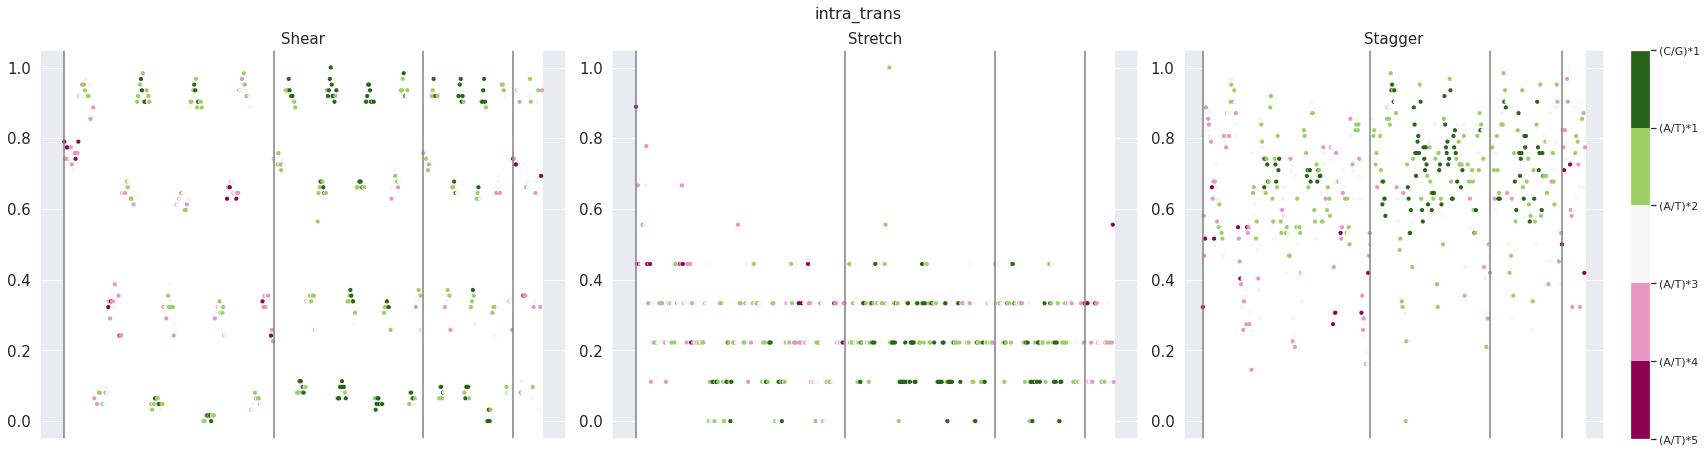

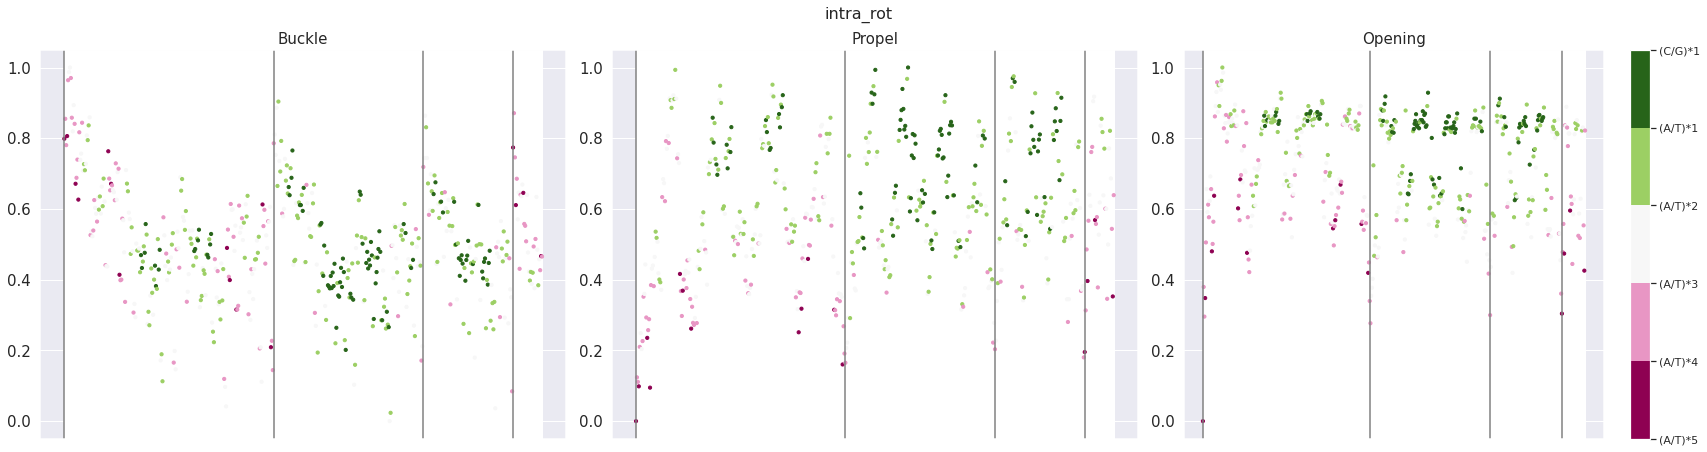

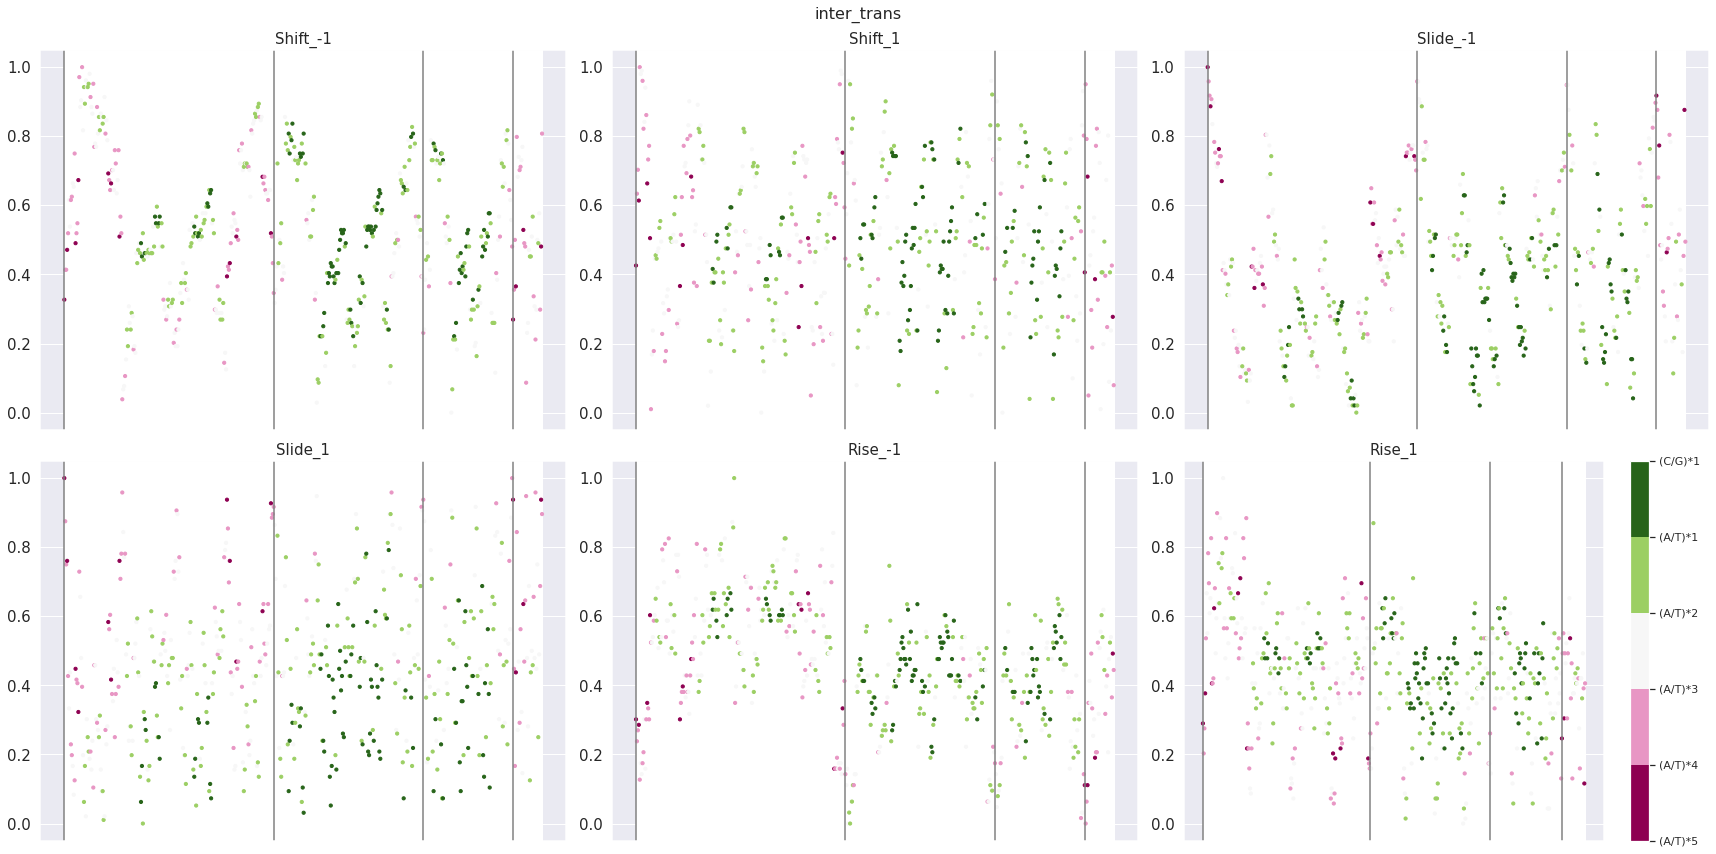

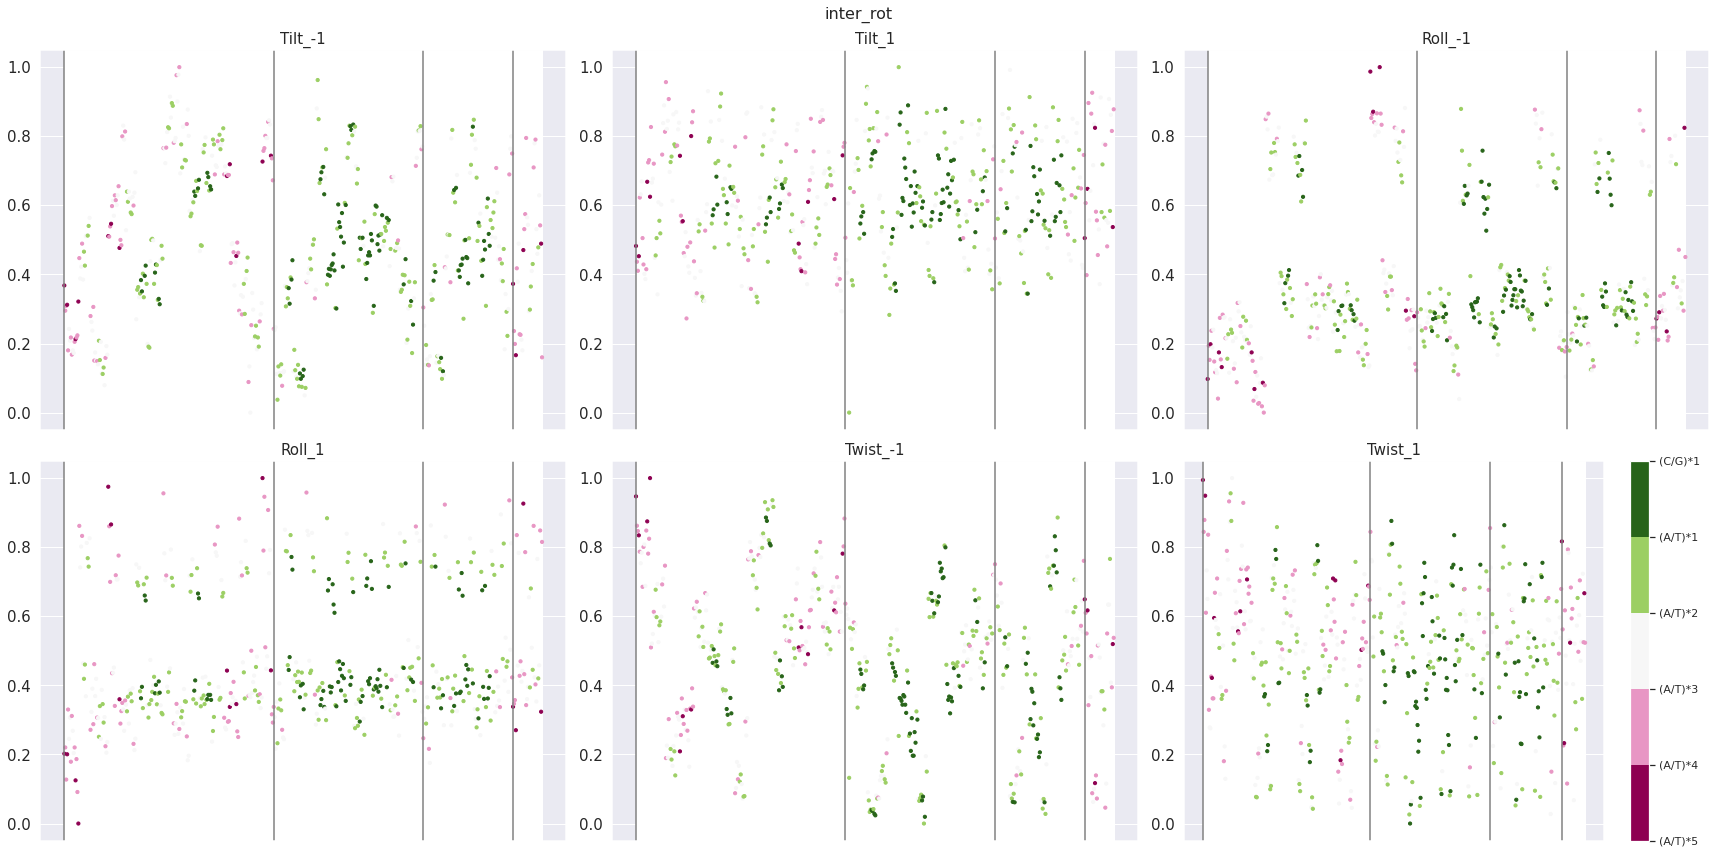

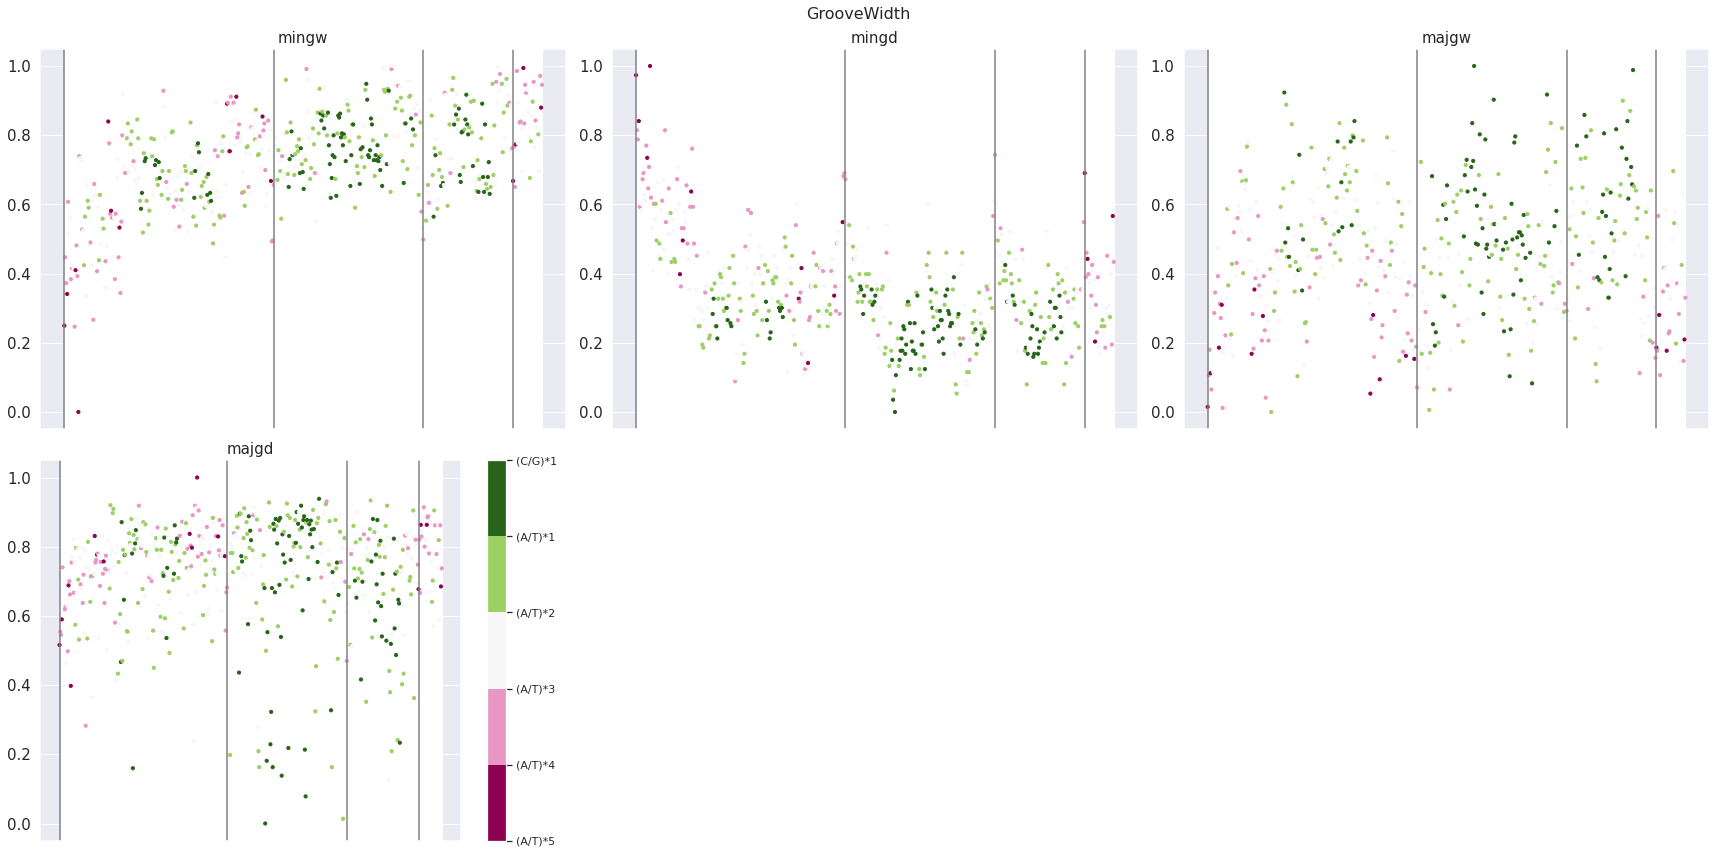

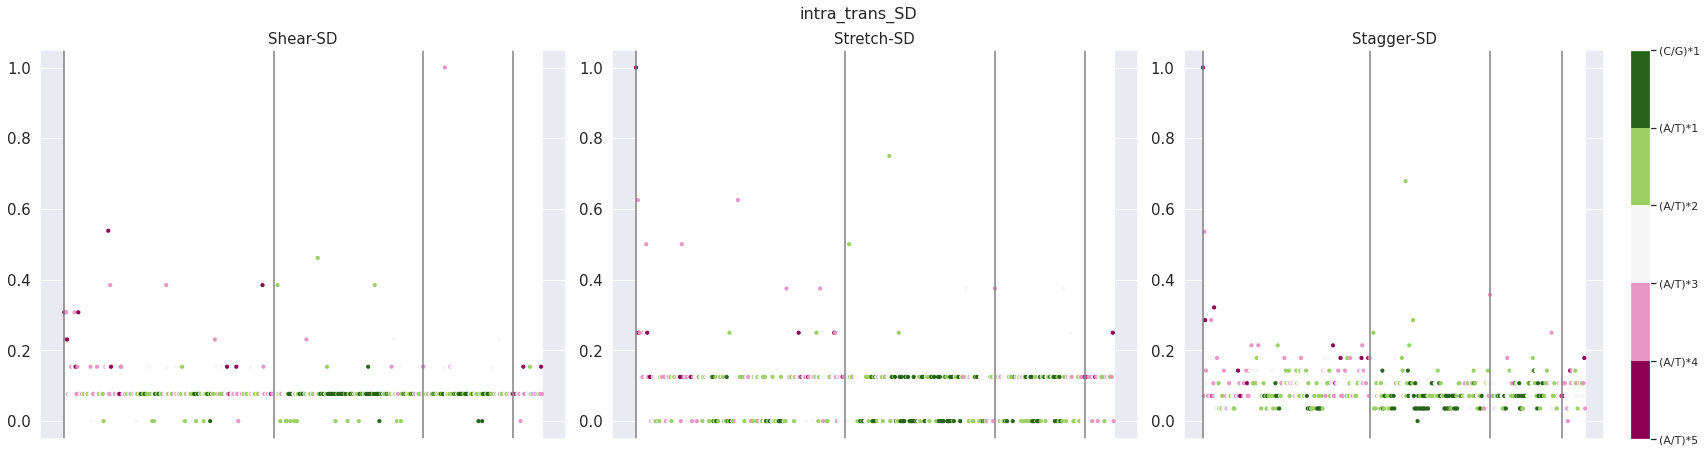

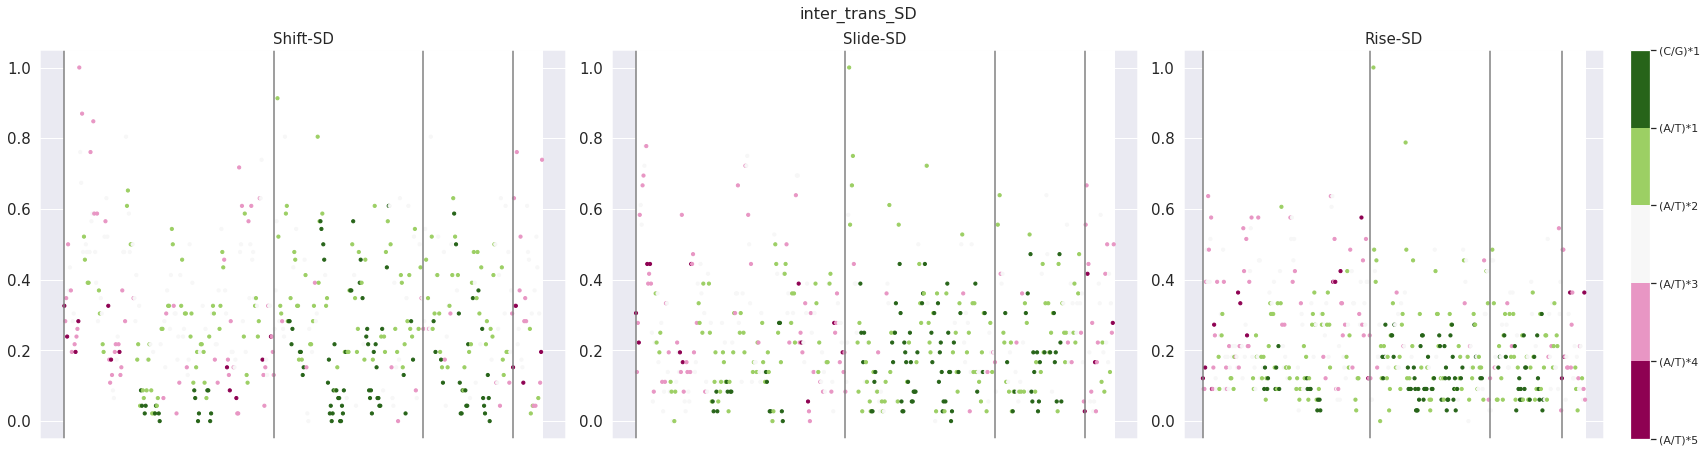

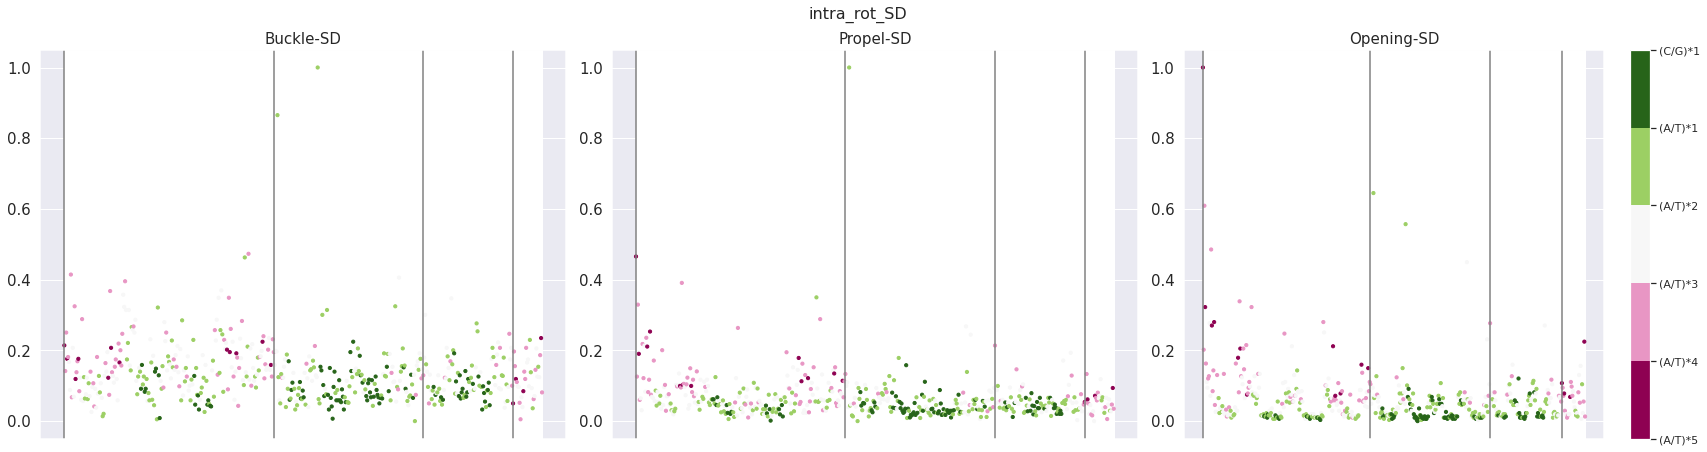

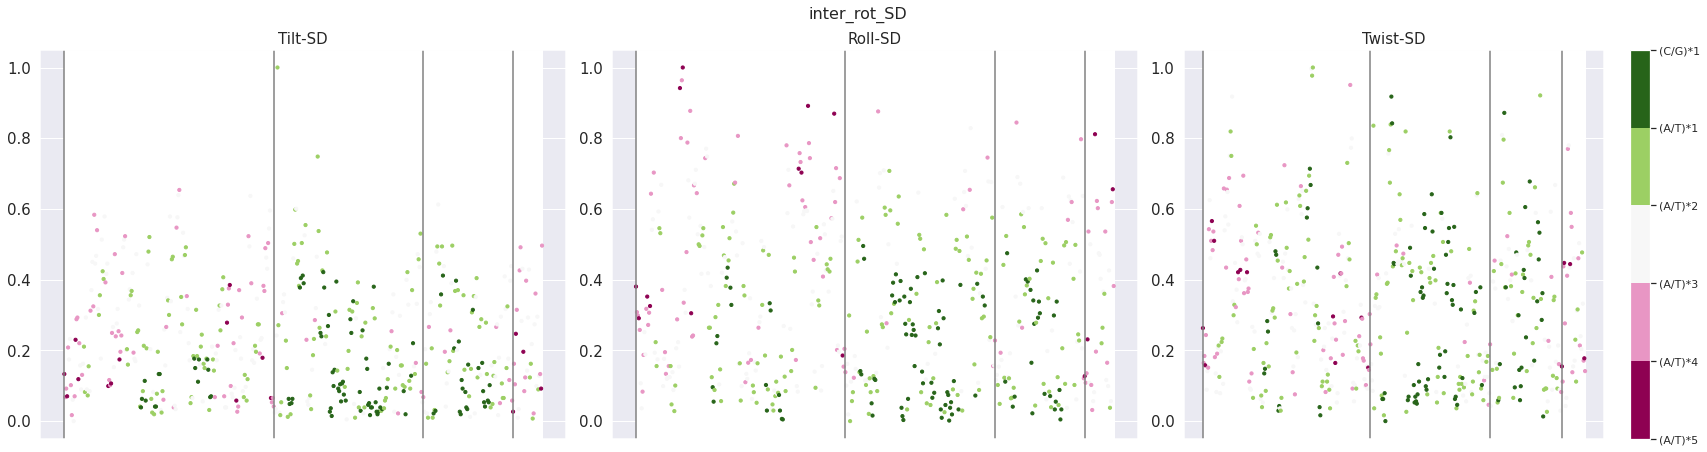

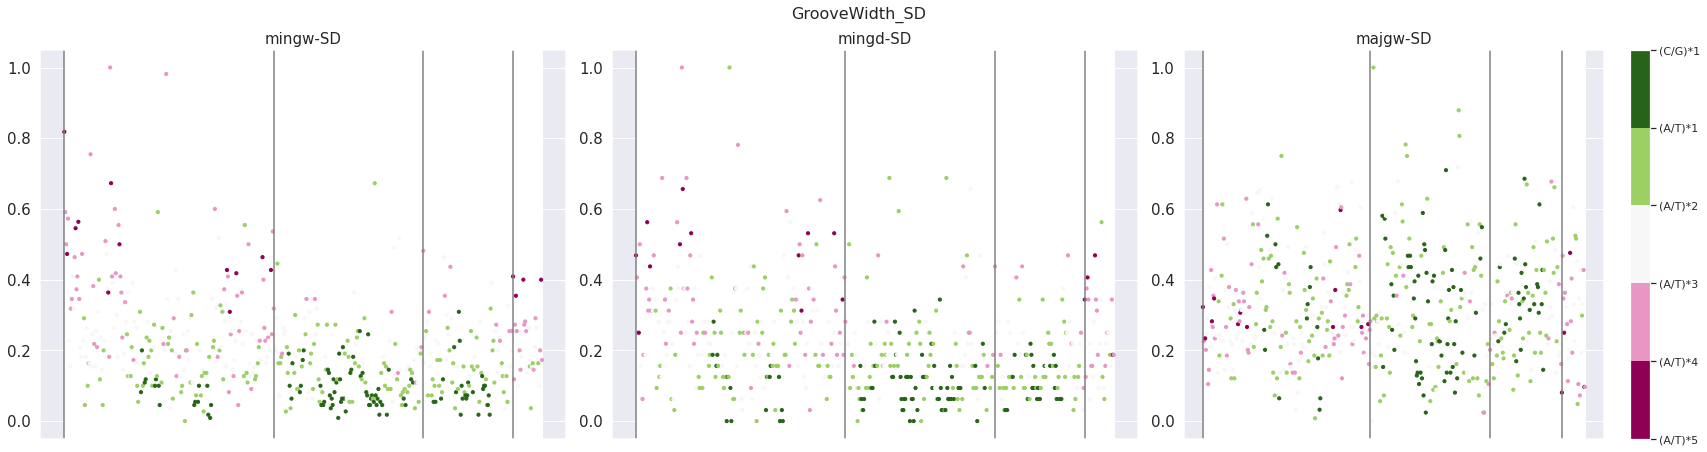

In [41]:
#################################### DNA Shape values ####################################
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.spines 
from matplotlib.ticker import PercentFormatter
import  matplotlib.cm as cm

all_norm_shape_vals, all_shape_vals2 = shape_param_analysis(tb)

for i in range(len(All_params)):
# for i in range(2):
    pic_index = All_params[i]
    fig = plt.figure(figsize=(24,12))
    fig.suptitle(All_params_names[i], fontsize=16)
    total_plot_num = len(pic_index)
#     for j in range(2):
    for j in range(len(pic_index)):

        # Set up the plot
        ax = plt.subplot(2, 3, j+1)
    
        # Draw the plot
        x = all_norm_shape_vals[pic_index[j]]
        
        ############ AT option
#         cols = AtackColor(tb)
#         plt.scatter(tb.keys(), x, s=10, c=cols, cmap=cm.get_cmap('PiYG', 10))
        ############ CG option
        cols = CGColor(tb)
        plt.scatter(tb.keys(), x, s=10, c=cols, cmap=cm.get_cmap('PiYG', 5))
        
        plt.tick_params(
            axis='x',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            bottom=False,      # ticks along the bottom edge are off
            top=False,         # ticks along the top edge are off
            labelbottom=False) # labels along the bottom edge are off
        plt.tick_params(
            axis='y',          # changes apply to the x-axis
            labelsize=15) # labels along the bottom edge are off
#         Title and labels
        ax.set_title('%s' % AllDNAshape[pic_index[j]], size = 15)
        ax.axvline(x='AAAAA', color='grey')
        ax.axvline(x='CAAAA', color='grey')
        ax.axvline(x='GAAAA', color='grey')
        ax.axvline(x='TAAAA', color='grey')
        [i.set_linewidth(1.5) for i in ax.spines.values()]
        
    plt.tight_layout()
    cbar = plt.colorbar()
#     cbar = fig.colorbar(ticks=range(1,1))
    ############ AT option
    cbar.ax.set_yticklabels(['(A/T)*5', '(A/T)*4', '(A/T)*3', '(A/T)*2', '(A/T)*1','(C/G)*1', '(C/G)*2', '(C/G)*3', '(C/G)*4', '(C/G)*5']) 

    ############ CG option
    plt.savefig(All_params_names[i]+"_scatter.jpg")
    plt.show()